In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The import statement below is specific so it will need to be changed if anyone wants to run this notebook by themselves, but since this is likely going into a broader script, the functions are the main takeaway. 

In [3]:
# import dataset
soil = pd.read_csv('/Users/hannahperez/Downloads/Station1_raw_merged.csv')

### Sanity Checks

In [5]:
soil.head()

,Unnamed: 0,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
0,2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,0.0,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
1,2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,0.0,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2,2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,0.0,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
3,2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,0.0,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
4,2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,0.0,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105


In [6]:
soil.rename(columns = {'Unnamed: 0': 'Date'}, inplace = True)
soil['Date'] = pd.to_datetime(soil['Date'])
soil.head()

,Date,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
0,2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,0.0,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
1,2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,0.0,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2,2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,0.0,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
3,2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,0.0,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
4,2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,0.0,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105


In [7]:
soil.tail()

,Date,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
57906,2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,0.0,29.10,60.19,0.610,197.1,0.0,30.3989,-98.6105
57907,2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,0.0,28.07,62.28,0.510,199.6,0.0,30.3989,-98.6105
57908,2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,0.0,27.73,63.98,1.417,192.6,0.0,30.3989,-98.6105
57909,2021-08-31 23:00:00,0.0,0.096,0.102,0.104,0.106,32.07,32.89,32.94,30.13,0.0,27.30,67.31,1.741,190.2,0.0,30.3989,-98.6105
57910,2021-09-01 00:00:00,0.0,0.095,0.102,0.103,0.106,31.50,32.39,32.62,30.21,0.0,26.21,74.82,1.617,197.9,0.0,30.3989,-98.6105


### Temperature

This dataset doesn't appear to have null values so I can't really test these functions, but they'll still be here once I find the appropriate dataset with things not taken out. I believe that dates lacking info were simply taken out as it seems as though there's information for all entries

In [10]:
# takes dataframe df and string column to be filled 
def fill_avg(df, column): 
    new_df = df.copy()
    new_df['month'] = df['Date'].dt.month
    new_df['day'] = df['Date'].dt.day
    new_df['hour'] = df['Date'].dt.hour

    missing = new_df[new_df[column].isna()]
    
    for i in missing.index.tolist(): 
        date = new_df.iloc[[i]]['Date'].values[0]
        new_date = pd.Series([date])
        month = int(new_date.dt.month.iloc[0])
        day = int(new_date.dt.day.iloc[0])
        hour = int(new_date.dt.hour.iloc[0])

        slice = new_df[(new_df['month'] == month) & (new_df['day'] == day) & (new_df['hour'] == hour)]
        new_df.loc[i, column] = slice[column].mean()
    return new_df

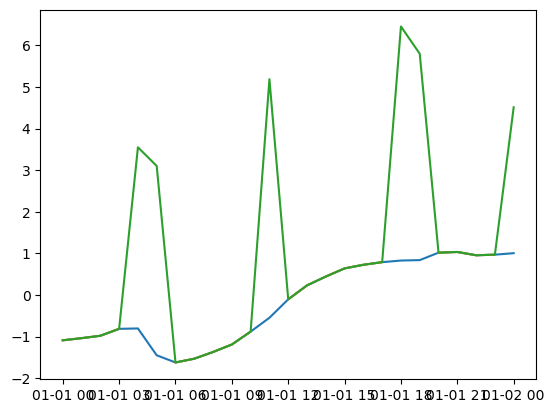

In [112]:
df = soil.copy(deep = True)
missing_sample = np.random.randint(low = 0, high = 25, size = 10)

for i in missing_sample:
    df.loc[i, 'Tair'] = np.nan

testing = fill_avg(df, 'Tair')

plt.plot(soil.iloc[:25]['Date'], soil.iloc[:25]['Tair'])
plt.plot(df.iloc[:25]['Date'], df.iloc[:25]['Tair'])
plt.plot(testing.iloc[:25]['Date'], testing.iloc[:25]['Tair'])

### Srad

#### Sunrise, Sunset, and Peaks
First, we analyze the behavior of solar radiation manually since there is a clear seasonality.

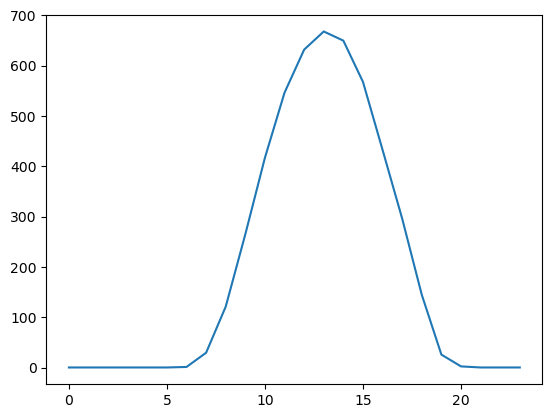

In [13]:
new_soil = soil.copy()
new_soil['year'] = soil['Date'].dt.year
new_soil['month'] = soil['Date'].dt.month
new_soil['day'] = soil['Date'].dt.day
new_soil['hour'] = soil['Date'].dt.hour
avg_srad_per_hour = new_soil.groupby('hour')['Srad'].mean()
plt.plot([i for i in range(24)], avg_srad_per_hour.values)

This shows us a clear daily trend with a peak around noon and near zero values before and after certain hours. Below is a similar plot for only January that allows us to see how the hour of these extreme values may differ month by month. With this in mind, the next section finds "sunrise", "sunset", and "peak" hours for each month

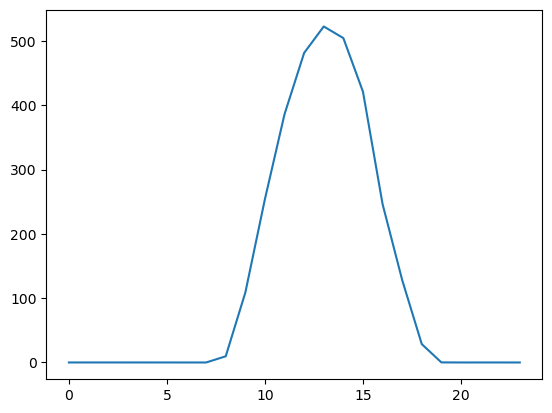

In [116]:
avg_srad_per_hour_year = new_soil[new_soil['month'] == 1].groupby('hour')['Srad'].mean()
plt.plot([i for i in range(24)], avg_srad_per_hour_year.values)

Our definitions of sunrise and sunset are as follows:
* Sunrise: Take the average Srad of every hour for a given month and then determine at which hours Srad jumps from below zero to above zero
* Sunset: Take the average Srad of every hour for a given month and then determine at which hours Srad jumps from above zero to below zero
* Peak: Take the average Srad of every hour for a given month and then determine at which hour the maximum amount of Srad is

In order to fit in with later functions using this information, the actual time of sunrise is determined as the time of the first "above zero" value and sunset is determined as the time of the last "above zero" value. If you look at each month individually, some Srad values will rise and then fall. This is likely the result of cloudcover, but taking the averages of the same month in different years smooths this out. 

On initial testing, April presented as an outlier because solar radiation never fell below one for any hour. This demands further exploration that can be found below this section, but for the purpose of being able to continue progress elsewhere, I've hardcoded some times. The reasoning for my choices of times can be found in the aforementioned "April Srad" section. 

In [156]:
# identify sunset and sunrise times by the month (adjust this later if substantial upward trend is found)
# tuples in form (month, sunrise, peak, sunset)
rise_set_times = []
for i in range(1, 13):
    avg_srad_per_hour_month = new_soil[new_soil['month'] == i].groupby('hour')['Srad'].mean()
    l = avg_srad_per_hour_month.tolist()
    tf = [j < 1 for j in l]
    if i == 4:
        rise_set_times.append((4, 7, 13, 19))
    else:
        sunrise = tf.index(False)
        sunset = tf.index(True, sunrise) - 1
        peak = l.index(max(l))
        rise_set_times.append((i, sunrise, peak, sunset))

print(rise_set_times)

[(1, 8, 13, 18), (2, 8, 13, 19), (3, 7, 13, 19), (4, 7, 13, 19), (5, 6, 13, 20), (6, 6, 13, 20), (7, 6, 13, 20), (8, 7, 13, 20), (9, 7, 13, 19), (10, 7, 13, 18), (11, 8, 13, 18), (12, 8, 13, 18)]


Monthly Breakdown (sunrise - peak - sunset):
* January: 8 - 13 - 18
* February: 8 - 13 - 19
* March: 7 - 13 - 19
* April: 7 - 13 - 19
* May: 6 - 13 - 20
* June: 6 - 13 - 20
* July: 6 - 13 - 20
* August: 7 - 13 - 20
* September: 7 - 13 - 19
* October: 7 - 13 - 18
* November: 8 - 13 - 18
* December: 8 - 13 - 18

#### April Srad

When trying to find the sunset, sunrise, and peak times, April specifically threw an error because the average solar radiation per hour never drops below 1. This is something we need to look into further, but for now I will decide that sunrise is between 6 and 7, sunset is between 19 and 20, and the peak is at 13 based on the data below. Further exploration into April outliers that would cause this will be done in this section. 

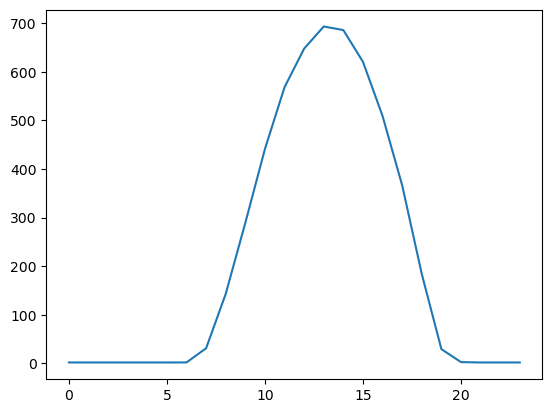

In [148]:
avg_srad_per_hour_year = new_soil[new_soil['month'] == 4].groupby('hour')['Srad'].mean()
plt.plot([i for i in range(24)], avg_srad_per_hour_year.values)

In [150]:
avg_srad_per_hour_year

hour
0       2.011753
1       2.007474
2       2.024175
3       2.029845
4       2.036546
5       2.015309
6       2.107784
7      31.280206
8     143.224175
9     289.366425
10    441.269534
11    568.459741
12    647.768808
13    693.319067
14    685.894560
15    620.634041
16    509.076684
17    366.458912
18    184.022487
19     29.476114
20      2.747254
21      2.028083
22      2.004249
23      2.008342
Name: Srad, dtype: float64

In [163]:
april = new_soil[new_soil['month'] == 4]
april['year'].value_counts()

year
2015    720
2016    720
2017    720
2019    720
2020    720
2021    720
2018    321
Name: count, dtype: int64

In [165]:
years = [2015 + i for i in range(7)]
for i in years:
    avg_srad_per_hour_year = april[april['year'] == i].groupby('hour')['Srad'].mean()
    print(avg_srad_per_hour_year.tolist())

[0.057, 0.023000000000000003, 0.05666666666666667, 0.05233333333333333, 0.034, 0.01933333333333333, 0.14566666666666667, 30.994000000000003, 135.486, 277.26599999999996, 405.8566666666667, 540.1193333333333, 600.629, 687.8203333333333, 663.0236666666666, 574.1669999999999, 498.7683333333334, 351.27833333333336, 165.64766666666668, 23.83966666666667, 0.225, 0.03333333333333333, 0.007000000000000001, 0.012666666666666666]
[0.008333333333333333, 0.029, 0.06466666666666666, 0.11866666666666667, 0.06233333333333334, 0.026333333333333334, 0.10466666666666667, 23.062, 123.00266666666667, 247.98166666666665, 396.17266666666666, 512.9743333333333, 622.1423333333333, 645.0536666666667, 639.5383333333334, 584.7346666666667, 483.0506666666667, 344.41866666666664, 182.636, 38.727333333333334, 3.5409999999999995, 0.12066666666666667, 0.006666666666666666, 0.022666666666666665]
[0.07233333333333333, 0.10766666666666666, 0.12766666666666668, 0.094, 0.13866666666666666, 0.09233333333333334, 0.232666666

In [172]:
avg_srad_per_hour_year = april[april['year'] == 2018].groupby('hour')['Srad'].mean()
print(avg_srad_per_hour_year.tolist())

[27.457142857142856, 27.457142857142856, 27.457142857142856, 27.457142857142856, 27.457142857142856, 27.457142857142856, 27.525714285714287, 44.42857142857143, 128.87785714285715, 245.14076923076922, 394.2338461538462, 518.5384615384615, 607.2461538461538, 649.8846153846154, 623.7461538461538, 564.5, 448.8692307692308, 328.9384615384615, 169.70076923076925, 48.81153846153846, 29.573076923076922, 29.580769230769228, 29.569230769230767, 29.569230769230767]


In [179]:
april[april['year'] == 2018]['day'].value_counts()

day
1     24
2     24
3     24
4     24
5     24
6     24
7     24
8     24
9     24
10    24
11    24
12    24
13    24
14     9
Name: count, dtype: int64

In [181]:
report = []
for i in range(1, 15):
    day = april[(april['day'] == i) & (april['year'] == 2018)]['Srad'].tolist()
    day_tf = [j < 1 for j in day]
    if not(True in day_tf):
        report.append(i)

print(report)

[13, 14]


In [183]:
april[(april['day'] == 13) & (april['year'] == 2018)]['Srad']

28752    192.2
28753    192.2
28754    192.2
28755    192.2
28756    192.2
28757    192.2
28758    192.2
28759    192.2
28760    192.2
28761    192.2
28762    192.2
28763    192.2
28764    192.2
28765    192.2
28766    192.2
28767    192.2
28768    192.2
28769    192.2
28770    192.2
28771    192.2
28772    192.2
28773    192.2
28774    192.2
28775    192.2
Name: Srad, dtype: float64

In [185]:
april[(april['day'] == 14) & (april['year'] == 2018)]['Srad']

28776    192.2
28777    192.2
28778    192.2
28779    192.2
28780    192.2
28781    192.2
28782    192.2
28783    192.2
28784    192.2
Name: Srad, dtype: float64

Looking at this data, we see that April 2018 presents as a substantial outlier with other Aprils having values below 1 in the morning and at night as expected. Day 13 and 14 are the primary problems and recorded 192.2 for every value during those days. 

#### Other Junk

In [114]:
# find the minimum and maximum for each 
l = []

for i in range(1, 13):
    minimum = new_soil[(new_soil['month'] == i) & (new_soil['hour'] == 13) & (new_soil['year'] == 2015)]['Srad'].min()
    maximum = new_soil[(new_soil['month'] == i) & (new_soil['hour'] == 13) & (new_soil['year'] == 2015)]['Srad'].max()
    l.append(maximum - minimum)

avg = sum(l)/len(l)
print(avg)

746.9825000000001


In [ ]:
plt.plot(new_soil.iloc[])

In [106]:
new_soil.iloc[:743] # month of January for 2015


,Date,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,...,RH,Windspeed,Winddirection,Srad,Latitude,Longitude,year,month,day,hour
730,2015-01-31 10:00:00,0.00,0.149,0.198,0.172,0.188,11.44,12.19,12.83,14.10,...,97.1,1.871,165.7,25.24,30.3989,-98.6105,2015,1,31,10
731,2015-01-31 11:00:00,0.25,0.149,0.198,0.172,0.188,11.48,12.15,12.75,14.07,...,96.7,2.685,170.0,54.86,30.3989,-98.6105,2015,1,31,11
732,2015-01-31 12:00:00,0.25,0.149,0.198,0.172,0.187,11.75,12.15,12.68,14.01,...,97.7,3.194,168.5,84.86,30.3989,-98.6105,2015,1,31,12
733,2015-01-31 13:00:00,1.52,0.150,0.198,0.172,0.188,12.01,12.26,12.66,13.98,...,97.1,2.551,178.9,87.19,30.3989,-98.6105,2015,1,31,13
734,2015-01-31 14:00:00,0.25,0.156,0.198,0.172,0.187,12.49,12.40,12.69,13.93,...,97.7,2.374,182.0,106.94,30.3989,-98.6105,2015,1,31,14
735,2015-01-31 15:00:00,0.00,0.163,0.199,0.172,0.187,12.85,12.63,12.75,13.88,...,98.2,2.572,182.4,110.80,30.3989,-98.6105,2015,1,31,15
736,2015-01-31 16:00:00,0.51,0.167,0.199,0.172,0.187,13.26,12.87,12.85,13.85,...,98.1,2.069,175.6,61.05,30.3989,-98.6105,2015,1,31,16
737,2015-01-31 17:00:00,1.78,0.178,0.199,0.172,0.187,13.21,13.05,12.98,13.82,...,98.4,1.611,195.0,21.41,30.3989,-98.6105,2015,1,31,17
738,2015-01-31 18:00:00,0.76,0.194,0.201,0.171,0.187,13.05,13.09,13.08,13.79,...,95.0,3.972,176.8,19.41,30.3989,-98.6105,2015,1,31,18
739,2015-01-31 19:00:00,0.00,0.194,0.205,0.171,0.187,13.01,13.07,13.11,13.77,...,95.1,2.096,217.9,0.71,30.3989,-98.6105,2015,1,31,19


In [98]:
new_soil[(new_soil['month'] == 1) & (new_soil['hour'] == 13) & (new_soil['year'] == 2015)]['Srad'].mean()

430.7216129032259

### Short Gaps in Srad
We define short gaps here by less than 24 hours. Since the seasonality is tied so strongly to day and night cycles, we locate a peak in the data around 1:00 PM (fixing it with relevant averages if it is missing) and draw a line from the last hour we have to our missing point. If this is functions well enough, we can leave it. If not, we can create a more complicated function that creates a quadratic function to see if that improves our data as the chart of averages shows a distinctly quadratic shape.  

In [74]:
# function assumes this is a shortgap over the course of a day, functions for longer gaps can utilize this one
# as the function doesn't actually depend on any of the values within the given day having data
# takes dataframe df, string column, and missing date, gives back dataframe with missing values filled in
def short_gap_fill_srad(df, column, date): 
    new_df = df.copy()
    new_df['year'] = df['Date'].dt.year
    new_df['month'] = df['Date'].dt.month
    new_df['day'] = df['Date'].dt.day
    new_df['hour'] = df['Date'].dt.hour

    new_date = pd.Series([date])
    year = int(new_date.dt.year.iloc[0])
    month = int(new_date.dt.month.iloc[0])
    day = int(new_date.dt.day.iloc[0])
    hour = int(new_date.dt.hour.iloc[0])

    slice = new_df[(new_df['day'] == day) & (new_df['month'] == month) & (new_df['year'] == year)].reset_index()

    # check if the data for 1:00 is there, substitute average from previous years in the same month if not
    # this can be altered to restrict the window of data we're looking for if previous months ends up 
    # being inaccurate/out of place
    # FIX THIS, HIGHLY INACCURATE, NEXT TRY TAKE A COUPLE DAYS AROUND THE DAY WITH EXCEPTIONS FOR DATES AT THE END
    # AND THE BEGINNING
    if type(slice.loc[13, column]) != float:
        avg = new_df[(new_df['month'] == month) & (new_df['hour'] == 13) & (new_df['year'] == year)][column].mean()
        slice.loc[13, column] = avg

    # iterate over the dataframe for the given day and fill all gaps
    i = 0
    while i < 24: 
        if type(slice.loc[i, column]) != float:
            if i < 6: # this is a placeholder for the hour of sunrise, it can be adjusted later
                slice.loc[i, column] = 0.2 # this is a placeholder for the amount of solar radiation before sunrise
                i += 1
            elif i > 20: # this value and the one directly below operate similarly to the ones above except in regards to sunset
                slice.loc[i, column] = 0.2
                i += 1
            else: 
                j = i + 1
                while (type(slice.loc[j, column]) != float) and (j < 13): # find the next filled value to draw a line through
                    j += 1

                # draw a line from the first value before a missing value to the next filled value
                x1, y1 = i - 1, slice.loc[i - 1, column]
                x2, y2 = j, slice.loc[j, column]
                m = (y2 - y1)/(x2 - x1)

                # fill in the line
                for k in range(i + 1, j):
                    val = slice.loc[k - 1, column] + m
                    slice.loc[k, column] = val

                i = j 
        i += 1

    # incorporate slice into dataframe
    new_df.loc[(new_df['day'] == day) & (new_df['month'] == month) & (new_df['year'] == year)] = slice
    new_df.reset_index()
    return new_df

In [ ]:
# function assumes this is a shortgap over the course of a day, functions for longer gaps can utilize this one
# as the function doesn't actually depend on any of the values within the given day having data
# takes dataframe df, string column, and missing date, gives back dataframe with missing values filled in
def short_gap_fill_srad(df, column, date): 
    new_df = df.copy()
    new_df['year'] = df['Date'].dt.year
    new_df['month'] = df['Date'].dt.month
    new_df['day'] = df['Date'].dt.day
    new_df['hour'] = df['Date'].dt.hour

    new_date = pd.Series([date])
    year = int(new_date.dt.year.iloc[0])
    month = int(new_date.dt.month.iloc[0])
    day = int(new_date.dt.day.iloc[0])
    hour = int(new_date.dt.hour.iloc[0])

    slice = new_df[(new_df['day'] == day) & (new_df['month'] == month) & (new_df['year'] == year)].reset_index()
    date_idx = slice.index[slice['hour'] == hour].tolist()[0]

    # check if the data for 1:00 is there, substitute average from previous years in the same month if not
    # this can be altered to restrict the window of data we're looking for if previous months ends up 
    # being inaccurate/out of place
    
    if hour < sunrise:
        return sunrise_val
    elif hour > sunset:
        return sunset_val
    elif hour == peak:
        int_idx = df.index[df['Date'] == date].tolist()[0]
        if int_idx == 0:
            avg = new_df[new_df['hour'] == 13].iloc[1:3][column].mean()
        elif int_idx == df.shape[0]:
            avg = new_df[new_df['hour'] == 13].iloc[-3:-1][column].mean()
        else:
            avg = new_df[new_df['hour'] == 3].iloc[int_idx - 1: int_idx + 2][column].mean()
        
        slice.loc[13, column] = avg
    else:
        l_srad = slice['Srad'].tolist()
        tf_srad = [type(i) == float for i in l_srad]
        tf_srad_rev = [tf_srad[-i] for i in range(1, len(tf_srad) + 1)]
        stop = tf_srad.find(True, date_idx)
        start = len(tf_srad) - 1 - tf_srad_rev.find(True, len(tf_srad) - 1 - date_idx)
        start_srad = l_srad[start]
        stop_srad = l_srad[stop]
        m = (stop_srad - start_srad)/(stop - start)
        val = start_srad + ((date_idx - start) * m)
        return val


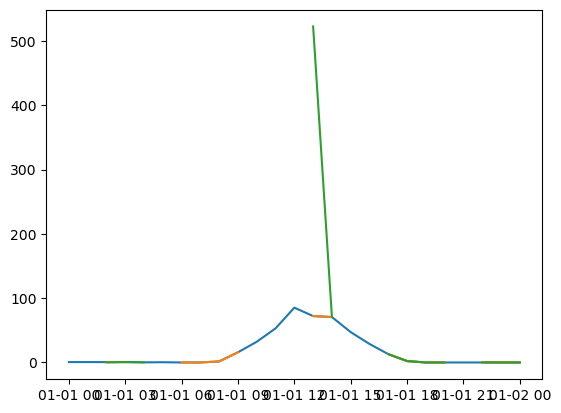

In [108]:
# test shortgap function
pd.options.mode.chained_assignment = None # default = 'warn'
df = soil.copy(deep = True)
missing_sample = np.random.randint(low = 0, high = 25, size = 10)

for i in missing_sample:
    df.loc[i, 'Srad'] = np.nan

testing = short_gap_fill_srad(df, 'Srad', soil.loc[missing_sample[0], 'Date'])

plt.plot(soil.iloc[:25]['Date'], soil.iloc[:25]['Srad'])
plt.plot(df.iloc[:25]['Date'], df.iloc[:25]['Srad'])
plt.plot(testing.iloc[:25]['Date'], testing.iloc[:25]['Srad'])

In [84]:
soil.iloc[:25]

,Date,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
0,2015-01-01 00:00:00,0.00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,0.000,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
1,2015-01-01 01:00:00,0.00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,0.000,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2,2015-01-01 02:00:00,0.00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,0.000,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
3,2015-01-01 03:00:00,0.00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,0.000,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
4,2015-01-01 04:00:00,0.00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,0.000,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105
5,2015-01-01 05:00:00,0.00,0.139,0.178,0.148,0.152,2.89,4.30,5.54,10.32,0.000,-1.450,96.5,1.035,46.66,0.39,30.3989,-98.6105
6,2015-01-01 06:00:00,0.00,0.139,0.178,0.148,0.152,2.73,4.25,5.51,10.27,0.000,-1.623,97.5,1.128,44.23,0.00,30.3989,-98.6105
7,2015-01-01 07:00:00,0.00,0.139,0.177,0.148,0.152,2.64,4.18,5.46,10.22,0.000,-1.532,97.8,0.818,55.48,0.01,30.3989,-98.6105
8,2015-01-01 08:00:00,0.00,0.139,0.177,0.148,0.152,2.64,4.11,5.39,10.17,0.000,-1.371,98.2,0.595,49.05,1.66,30.3989,-98.6105
9,2015-01-01 09:00:00,0.00,0.139,0.177,0.148,0.152,2.67,4.07,5.34,10.12,0.000,-1.191,98.7,0.821,61.78,15.86,30.3989,-98.6105


#### Window/Lag Data

In [19]:
def offset_regression(df, column, window): 
    x = []
    y = []
    start = 0
    finish = window
    while finish < df.shape[0]:
        lx = [df.iloc[j][column] for j in range(start, finish)]
        x.append(lx)
        y.append(df.iloc[finish][column])
        start += 1
        finish += 1

    X = pd.DataFrame(data = x)
    Y = pd.DataFrame(data = y)

    return X, Y
    
df = soil.iloc[:25]
column = 'Srad'
window = 5

X, Y = offset_regression(df, column, window)
X

,0,1,2,3,4
0,0.63,0.62,0.60,0.64,0.20
1,0.62,0.60,0.64,0.20,0.39
2,0.60,0.64,0.20,0.39,0.00
3,0.64,0.20,0.39,0.00,0.01
4,0.20,0.39,0.00,0.01,1.66
5,0.39,0.00,0.01,1.66,15.86
6,0.00,0.01,1.66,15.86,32.23
7,0.01,1.66,15.86,32.23,53.05
8,1.66,15.86,32.23,53.05,85.24
9,15.86,32.23,53.05,85.24,72.17


In [20]:
Y

,0
0,0.39
1,0.00
2,0.01
3,1.66
4,15.86
5,32.23
6,53.05
7,85.24
8,72.17
9,70.64
